In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# **Import Libraries** 

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.decomposition import TruncatedSVD
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score

# **Load Datasets**

In [30]:
train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_sub = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

In [31]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


# **Exploratory Data Analysis (EDA)**

In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


For checkng data types & missing values

In [33]:
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


Statistical summary

/tmp/ipykernel_55/2327308486.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train, palette='viridis')


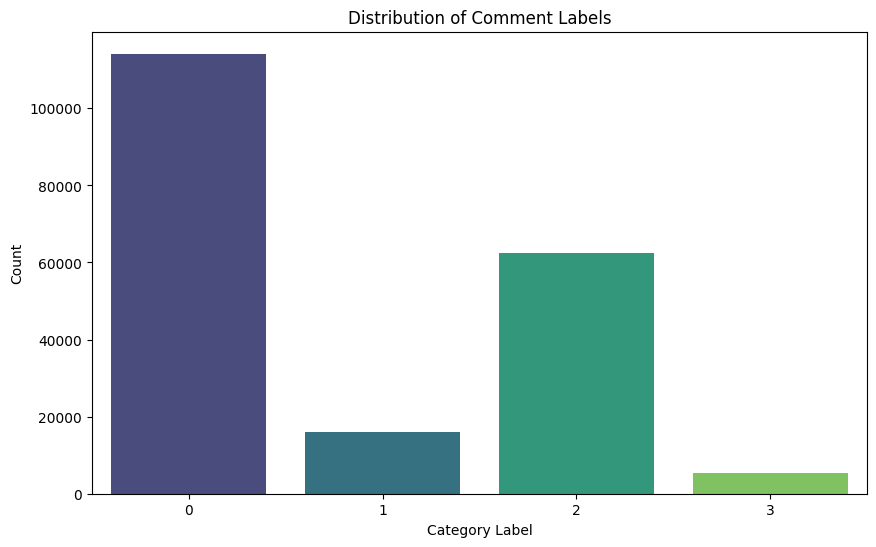

Label Percentages:
 label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64


In [34]:
# label distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=train, palette='viridis')
plt.title('Distribution of Comment Labels')
plt.xlabel('Category Label')
plt.ylabel('Count')
plt.show()


label_pct = train['label'].value_counts(normalize=True) * 100      # Percentage calculation
print("Label Percentages:\n", label_pct)

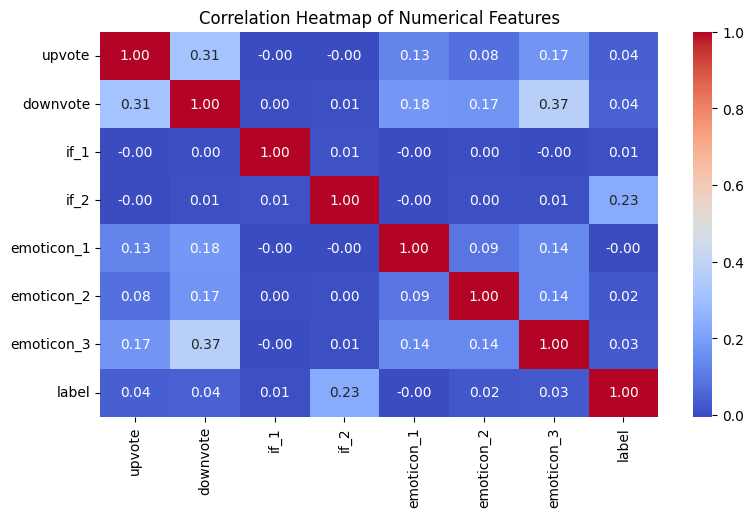

In [35]:
# Correlation matrix for numerical features
num_cols = ['upvote', 'downvote', 'if_1', 'if_2', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'label']
plt.figure(figsize=(9, 5))
sns.heatmap(train[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

* Red means high positive correlation, Blue means low or negative correlation
* No feature pair is highly correlated, So no serious multicollinearity problem
* Most values are close to 0, Features are mostly independent
* No single numeric feature strongly predicts the label, so text features are doing most of the heavy lifting
* Since relationships are weak, we can use non-linear models like Random Forest, XGBoost, LightGBM etc.

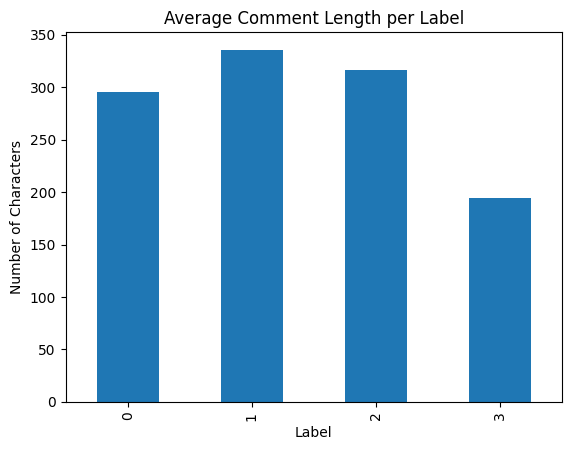

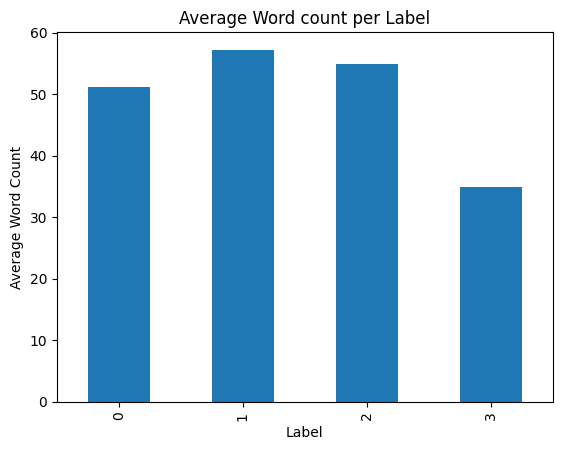

In [36]:
# Average comment length and word count per label

train['text_len'] = train['comment'].fillna('').apply(len)
train['word_count'] = train['comment'].fillna('').apply(lambda x: len(x.split()))


train.groupby('label')['text_len'].mean().plot(kind='bar')
plt.title('Average Comment Length per Label')
plt.xlabel('Label')
plt.ylabel('Number of Characters')
plt.show()

train.groupby('label')['word_count'].mean().plot(kind='bar')
plt.title('Average Word count per Label')
plt.ylabel('Average Word Count')
plt.xlabel('Label')
plt.show()

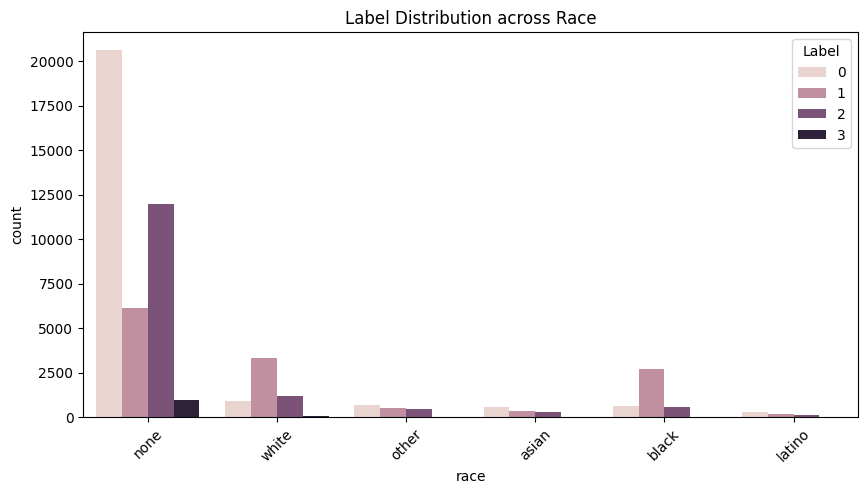

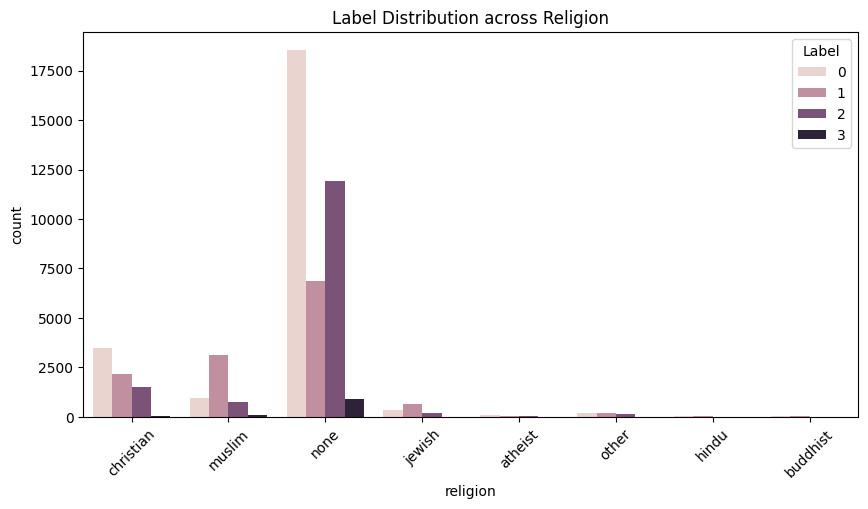

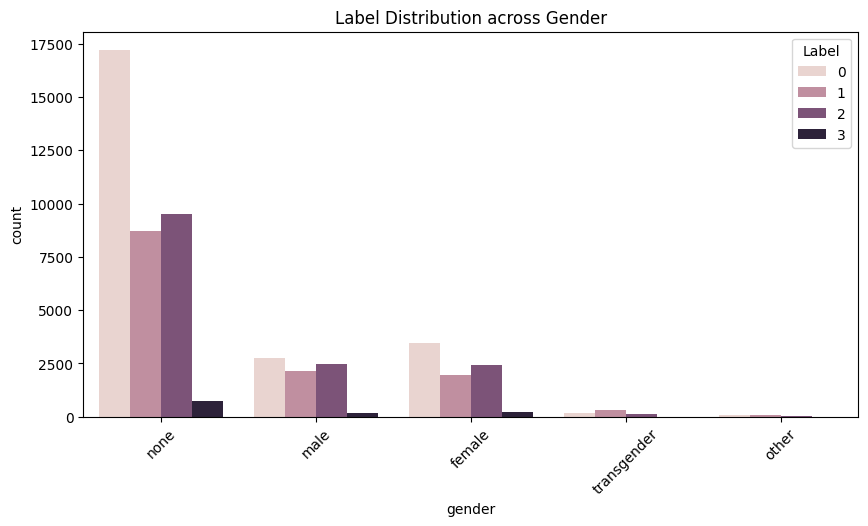

In [37]:
# Check for nulls in identity columns and visualize
identity_cols = ['race', 'religion', 'gender']

for col in identity_cols:
    plt.figure(figsize=(10, 5))
    # Filter out NaNs to see the distribution of tagged identities
    sns.countplot(x=col, hue='label', data=train.dropna(subset=[col]))
    plt.title(f'Label Distribution across {col.capitalize()}')
    plt.xticks(rotation=45)
    plt.legend(title='Label', loc='upper right')
    plt.show()

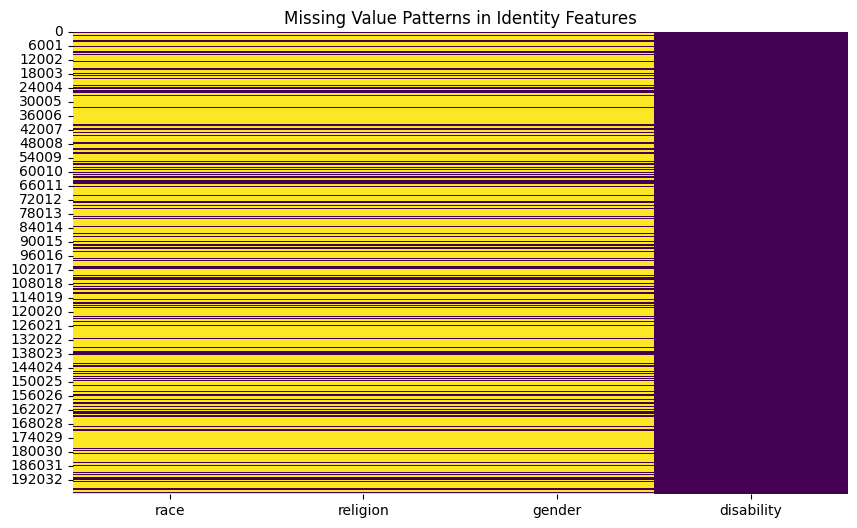

In [38]:
plt.figure(figsize=(10, 6))
sns.heatmap(train[['race', 'religion', 'gender', 'disability']].isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Patterns in Identity Features')
plt.show()

* These three features are co dependent. They aren't missing at random, they are missing as a block.
* If a user didn't provide their race, they likely didn't provide their religion or gender either.

/tmp/ipykernel_55/1534776097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='upvote', data=train, palette='viridis', estimator=np.mean)


Text(0, 0.5, 'Mean Upvotes')

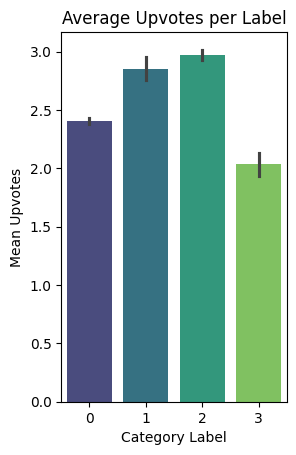

In [39]:
# Average Upvotes by Label
plt.subplot(1, 2, 1)
sns.barplot(x='label', y='upvote', data=train, palette='viridis', estimator=np.mean)
plt.title('Average Upvotes per Label')
plt.xlabel('Category Label')
plt.ylabel('Mean Upvotes')

/tmp/ipykernel_55/3960302891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='downvote', data=train, palette='magma', estimator=np.mean)


Text(0, 0.5, 'Mean Downvotes')

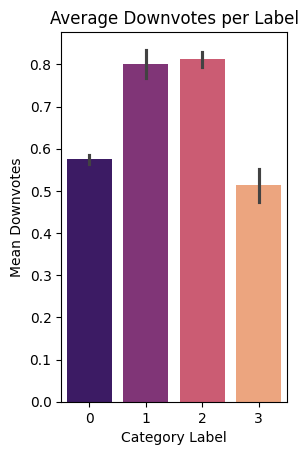

In [40]:
# Average Downvotes by Label
plt.subplot(1, 2, 2)
sns.barplot(x='label', y='downvote', data=train, palette='magma', estimator=np.mean)
plt.title('Average Downvotes per Label')
plt.xlabel('Category Label')
plt.ylabel('Mean Downvotes')

# **FEATURE ENGINEERING**

In [41]:
  def features(df):
      identity_cols = ['race', 'religion', 'gender']
      for col in identity_cols:
          df[col] = df[col].fillna('none').astype(str)          #Replace missing values with 'none' and Convert everything to string
    
      df['comment'] = df['comment'].fillna('').astype(str)      #All comments are strings, filling missing values with empty string
      df['text_len'] = df['comment'].apply(len)                 #Number of characters in each comment
     
      df['punc_count'] = df['comment'].apply(lambda x: x.count('!') + x.count('?'))        #More punctuation means more emotion or aggression
      df['caps_ratio'] = df['comment'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))     #Percentage of uppercase letters, all caps often means anger or emphasis
    
      df['vote_ratio'] = df['upvote'] / (df['downvote'] + 1)     #Popularity vs negativity
      df['net_votes'] = df['upvote'] - df['downvote']            #how much support
    
      df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')    #String to datetime format
      df['hour'] = df['created_date'].dt.hour.fillna(-1)
      df['is_weekend'] = df['created_date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
      df['disability'] = df['disability'].astype(int)
    
      return df

  train = features(train)
  test = features(test)

In [42]:
train.head(20)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,...,comment,label,text_len,word_count,punc_count,caps_ratio,vote_ratio,net_votes,hour,is_weekend
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,none,...,She might be a bright spot for a party keou on...,2,118,20,0,0.016807,0.000000,-1,8,0
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,none,...,"Under Alaska law, a non-tribal member is not b...",0,644,110,0,0.013953,6.000000,6,21,1
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,none,...,in the future please spare me your strawman dr...,2,751,133,0,0.017287,0.000000,0,20,0
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,none,...,"PS: That should have been ""rot"" instead of ""co...",2,91,15,0,0.043478,5.000000,5,22,1
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,none,...,"Today, the confederate flag...tomorrow, the na...",2,254,40,0,0.011765,0.000000,0,23,1
5,2024-04-06 20:10:59.141468+00:00,39,0,0,0,0,0,0,4,none,...,"Hilarious. Since it wasn't Trump, and that yaw...",0,127,20,0,0.023438,0.000000,0,20,1
6,2024-03-04 03:02:55.849172+00:00,72,0,0,0,0,0,0,4,none,...,Here's an Idea\nState Owned Foreign Companies ...,0,175,29,0,0.062500,0.000000,0,3,0
7,2023-10-14 20:57:30.208573+00:00,72,0,0,0,1,1,0,4,none,...,Victims' participation in the criminla justice...,0,92,14,0,0.010753,0.500000,0,20,1
8,2024-02-24 12:13:22.166045+00:00,71,0,0,0,0,0,6,6,none,...,I wonder what our ancestors would say when the...,0,171,27,0,0.023256,0.000000,0,12,1
9,2023-08-07 20:35:35.968324+00:00,72,1,0,0,6,2,0,4,none,...,I find it remarkbale that this comment is cons...,0,60,10,0,0.016393,2.000000,4,20,0


# **COLUMN SELECTORS**

In [43]:
  def get_numeric_features(df):
      cols = ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 
              'if_1', 'if_2', 'hour', 'text_len', 'punc_count', 'caps_ratio', 'vote_ratio', 'is_weekend', 'disability']
      return df[cols]

  def get_text_feature(df):
      return df['comment']

* select specific columns from the dataset and send them to the correct processing pipeline.

# **Preprocessing/Pipelines**

In [44]:
 text_pipe = Pipeline([
     ('selector', FunctionTransformer(get_text_feature, validate=False)),
     ('tfidf', TfidfVectorizer(max_features=15000, ngram_range=(1, 3), stop_words='english', min_df=3))
 ])

 numeric_pipe = Pipeline([
     ('selector', FunctionTransformer(get_numeric_features, validate=False)),
     ('imputer', SimpleImputer(strategy='median')),
     ('scaler', StandardScaler())
 ])

 processing_union = FeatureUnion([
     ('numeric', numeric_pipe),
     ('text', text_pipe)
 ])


# **Train-Test split**

In [45]:
X_train, X_val, y_train, y_val = train_test_split(train, train['label'], test_size=0.2, random_state=42, stratify=train['label'])

# **Models**

In [46]:
# DEFINE FOUR BASIC MODELS
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, tree_method='hist', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=200, learning_rate=0.1, num_leaves=31, class_weight='balanced', n_jobs=-1, random_state=42)
}

In [47]:
# TRAIN, COMPARE, AND EVALUATE BASIC MODELS
best_f1 = 0
best_model_name = ""
best_pipeline = None

for name, clf in models.items():
    print(f"\n Training {name}")
    current_pipeline = Pipeline([
        ('features', processing_union),
        ('classifier', clf)
    ])
    
    current_pipeline.fit(X_train, y_train)
    preds = current_pipeline.predict(X_val)
    
    current_f1 = f1_score(y_val, preds, average='weighted')
    print(f" Results for {name} (F1 Score: {current_f1:.4f}) ---")
    print(classification_report(y_val, preds))
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_model_name = name
        best_pipeline = current_pipeline


print(f"\n Best Model: {best_model_name} | F1 Score: {best_f1:.4f}")


 Training LogisticRegression
 Results for LogisticRegression (F1 Score: 0.9001) ---
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     22835
           1       0.67      0.85      0.75      3183
           2       0.88      0.85      0.87     12488
           3       0.45      0.78      0.57      1094

    accuracy                           0.89     39600
   macro avg       0.75      0.85      0.78     39600
weighted avg       0.91      0.89      0.90     39600


 Training RandomForest
 Results for RandomForest (F1 Score: 0.8444) ---
              precision    recall  f1-score   support

           0       0.96      0.93      0.95     22835
           1       0.55      0.84      0.66      3183
           2       0.90      0.63      0.74     12488
           3       0.22      0.78      0.35      1094

    accuracy                           0.83     39600
   macro avg       0.66      0.79      0.67     39600
weighted avg       0.89    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


 Results for LightGBM (F1 Score: 0.9047) ---
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.69      0.86      0.76      3183
           2       0.90      0.83      0.87     12488
           3       0.42      0.79      0.55      1094

    accuracy                           0.90     39600
   macro avg       0.75      0.86      0.78     39600
weighted avg       0.92      0.90      0.90     39600


 Best Model: LightGBM | F1 Score: 0.9047


# **Hyperparameter Tunning**

In [48]:
lgbm_grid = {'classifier__n_estimators': [100, 200], 'classifier__learning_rate': [0.05, 0.1], 'classifier__num_leaves': [31, 63]}
xgb_grid = {'classifier__n_estimators': [100, 150], 'classifier__max_depth': [5, 7], 'classifier__learning_rate': [0.05, 0.1]}
rf_grid = {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [10, 15]}

def tune_base_model(name, model, grid, X, y):
    print(f"\n Tuning {name} ")
    pipe = Pipeline([('features', processing_union), ('classifier', model)])
    search = RandomizedSearchCV(pipe, grid, n_iter=3, cv=3, scoring='f1_macro', verbose=1, random_state=42, n_jobs=-1)
    search.fit(X, y)
    return search.best_estimator_['classifier']


best_lgbm = tune_base_model("LightGBM", LGBMClassifier(class_weight='balanced', random_state=42), lgbm_grid, X_train, y_train)
best_xgb = tune_base_model("XGBoost", XGBClassifier(tree_method='hist', random_state=42), xgb_grid, X_train, y_train)
best_rf = tune_base_model("RandomForest", RandomForestClassifier(class_weight='balanced', random_state=42), rf_grid, X_train, y_train)


 Tuning LightGBM 
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 59.745547 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 617732
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 14903
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 49.756433 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 615910
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 14911
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] St

# **Tuned Models**

In [49]:
base_models_tuned = [
    ('lgbm', best_lgbm),
    ('xgb', best_xgb),
    ('rf', best_rf),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
]

# **Stacking**

In [53]:
stacking_clf = StackingClassifier(
    estimators=base_models_tuned,
    final_estimator=LogisticRegression(),
    cv=3
)

# **Final Training**

In [54]:
 final_pipeline = Pipeline([('features', processing_union), ('clf', stacking_clf)])
 final_pipeline.fit(train, train['label'])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 29.533389 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 971771
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 15013
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 18.890087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 727696
[LightGBM] [Info] Number of data points in the train set: 132000, number of used features: 14986
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] St

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 18.394106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 728527
[LightGBM] [Info] Number of data points in the train set: 132000, number of used features: 14986
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 18.446099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 729418
[LightGBM] [Info] Number of data points in the train set: 132000, number of used features: 14996
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('numeric',
                                                 Pipeline(steps=[('selector',
                                                                  FunctionTransformer(func=<function get_numeric_features at 0x7d1a215ee020>)),
                                                                 ('imputer',
                                                                  SimpleImputer(strategy='median')),
                                                                 ('scaler',
                                                                  StandardScaler())])),
                                                ('text',
                                                 Pipeline(steps=[('selector',
                                                                  FunctionTransformer(func=<function get_text_feature at 0x7d1a215ee660...
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=150,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...)),
                                                ('rf',
                                                 RandomForestClassifier(class_weight='balanced',
                                                                        max_depth=15,
                                                                        n_estimators=200,
                                                                        random_state=42)),
                                                ('lr',
                                                 LogisticRegression(class_weight='balanced',
                                                                    max_iter=1000))],
                                    final_estimator=LogisticRegression()))])

# **Prediction**

In [55]:
predictions = final_pipeline.predict(test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# **Submission**

In [56]:
 submission = pd.DataFrame({'ID': sample_sub['ID'], 'label': predictions})
 submission.to_csv('submission.csv', index=False)
 print("Submission file created")

Submission file created
